<a href="https://colab.research.google.com/github/rafiqy12/ml-radom-forest/blob/main/mls2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementasi Metode Klasifikasi Random Forest dengan Seleksi Fitur (Mirip C5.0)

Notebook ini bertujuan untuk mereplikasi metode klasifikasi dari paper "Improved Random Forest Classification Model Combined with C5.0 Algorithm" (Scientific Reports, 2024). Kami akan menggunakan `DecisionTreeClassifier` sebagai pendekatan yang setara untuk seleksi fitur, yang mirip dengan cara algoritma C5.0 digunakan untuk mengidentifikasi fitur penting sebelum membangun model Random Forest.

## 1. Import Library yang Diperlukan

Langkah pertama adalah mengimpor semua library Python yang akan kita gunakan untuk manipulasi data, preprocessing, pembangunan model, dan evaluasi.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier # Digunakan sebagai ekivalen C5.0 untuk seleksi fitur
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_selection import SelectFromModel
!pip install kaggle sentence-transformers scikit-learn pandas numpy

# Konfigurasi tampilan grafik
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100


## 2. mngunduh dataset

mengunduh dataset dari kggle


In [ ]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"rafiqyafta2329","key":"6586d33a64bd6c0d7b01e989a1dcb9bb"}'}

In [ ]:
# Instal pustaka opendatasets jika belum terinstal
!pip install opendatasets
import opendatasets as od
import os

# Anda sudah mengunggah kaggle.json Anda, sekarang kita bisa menggunakannya
# Jika kaggle.json ada di root /content/, pindahkan ke ~/.kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Unduh dataset dari Kaggle (Dataset Forest Cover Type)
kaggle_dataset_name = "uciml/forest-cover-type-dataset"
od.download(f"https://www.kaggle.com/datasets/{kaggle_dataset_name}")

# Path ke file CSV setelah diunduh
# Biasanya opendatasets akan membuat folder dengan nama dataset_name, dan file CSV-nya adalah 'covtype.csv'
landsat_dataset_path = f'./{kaggle_dataset_name.split("/")[1]}/covtype.csv'
print(f"Dataset Forest Cover Type diperkirakan berada di: {landsat_dataset_path}")


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: rafiqyafta2329
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset


100%|██████████| 11.2M/11.2M [00:01<00:00, 8.10MB/s]



Dataset Forest Cover Type diperkirakan berada di: ./forest-cover-type-dataset/covtype.csv


In [ ]:
import pandas as pd

# Ganti dengan path dataset Forest Cover Type yang sudah diunduh
try:
    # Gunakan variabel landsat_dataset_path yang didefinisikan sebelumnya (nama sedikit misleading, tapi path-nya benar)
    df = pd.read_csv(landsat_dataset_path)
    print("Dataset Forest Cover Type berhasil dimuat.")
    print("\nLima baris pertama dataset:")
    display(df.head())
    print("\nInformasi dataset:")
    df.info()

    # Tampilkan nama kolom untuk membantu identifikasi kolom target
    print("\nNama-nama Kolom di Dataset:")
    print(df.columns.tolist())

    # PENTING: Anda perlu mengidentifikasi nama kolom target yang benar di dataset ini. Untuk Forest Cover Type, biasanya 'Cover_Type'.
    # JANGAN LUPA MENGGANTI 'target_column_name_placeholder' di sel 9c6cd846 dan a44fdf78 juga!
    print("\nPeriksa daftar kolom di atas dan tentukan nama kolom target yang benar. Untuk dataset ini, kemungkinan besar 'Cover_Type'.")

except FileNotFoundError:
    print(f"Error: Dataset Forest Cover Type tidak ditemukan di '{landsat_dataset_path}'.")
    print("Pastikan path file benar dan dataset sudah berhasil diunduh dari Kaggle.")
    df = None
except Exception as e:
    print(f"Terjadi kesalahan saat memuat dataset: {e}")
    df = None


Dataset Forest Cover Type berhasil dimuat.

Lima baris pertama dataset:


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5



Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                

## 3. Menangani Missing Value

Kita akan memeriksa keberadaan missing value dan menanganinya. Strategi umum adalah mengisi nilai numerik yang hilang dengan median/mean atau menghapus baris/kolom yang memiliki terlalu banyak missing value. Untuk contoh ini, kita akan mengisi missing value numerik dengan median dan missing value kategorikal dengan modus, atau menghapus baris jika masih ada missing value yang signifikan.

In [ ]:
if df is not None:
    print("\nJumlah missing value per kolom:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

    # Menangani missing value numerik (contoh: dengan median)
    for col in df.select_dtypes(include=np.number).columns:
        if df[col].isnull().any():
            df[col].fillna(df[col].median(), inplace=True)

    # Menangani missing value kategorikal (contoh: dengan modus)
    for col in df.select_dtypes(include='object').columns:
        if df[col].isnull().any():
            df[col].fillna(df[col].mode()[0], inplace=True)

    print("\nMissing value setelah penanganan:")
    print(df.isnull().sum().sum())

    if df.isnull().sum().sum() > 0:
        print("Masih ada missing values, menghapus baris yang tersisa.")
        df.dropna(inplace=True)
        print(f"Ukuran dataset setelah menghapus missing values: {df.shape}")


Jumlah missing value per kolom:
Series([], dtype: int64)

Missing value setelah penanganan:
0


## 4. Melakukan Preprocessing Data

Langkah ini melibatkan encoding variabel kategorikal dan scaling fitur numerik. Kita akan menggunakan `LabelEncoder` untuk variabel target (jika kategorikal) dan `StandardScaler` untuk fitur numerik.

In [ ]:
if df is not None:
    # Identifikasi kolom numerik dan kategorikal
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(include='object').columns.tolist()

    # Hapus kolom target dari daftar jika sudah diketahui
    # Contoh: 'target_column_name' adalah nama kolom target Anda
    # Untuk dataset MNIST, kita asumsikan kolom pertama (indeks 0) adalah target
    target_column_name = 'Cover_Type' # GANTI DENGAN NAMA KOLOM TARGET ANDA: Sekarang 'Cover_Type'
    if target_column_name in numerical_cols:
        numerical_cols.remove(target_column_name)
    elif target_column_name in categorical_cols:
        categorical_cols.remove(target_column_name)

    # Encoding variabel kategorikal (selain target) menggunakan One-Hot Encoding
    # Ini diperlukan agar model dapat memprosesnya
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # Scaling fitur numerik
    scaler = StandardScaler()
    if numerical_cols:
        df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
        print("Fitur numerik berhasil di-scaling.")
    else:
        print("Tidak ada fitur numerik yang perlu di-scaling.")

    print("\nDataset setelah preprocessing (beberapa baris pertama):")
    display(df.head())


Fitur numerik berhasil di-scaling.

Dataset setelah preprocessing (beberapa baris pertama):


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,-1.297805,-0.935157,-1.482820,-0.053767,-0.796273,-1.180146,0.330743,0.439143,0.142960,3.246283,...,-0.315238,-0.290284,-0.05273,-0.057143,-0.014313,-0.022653,-0.165956,-0.156014,-0.123654,5
1,-1.319235,-0.890480,-1.616363,-0.270188,-0.899197,-1.257106,0.293388,0.590899,0.221342,3.205504,...,-0.315238,-0.290284,-0.05273,-0.057143,-0.014313,-0.022653,-0.165956,-0.156014,-0.123654,5
2,-0.554907,-0.148836,-0.681563,-0.006719,0.318742,0.532212,0.816364,0.742654,-0.196691,3.126965,...,-0.315238,-0.290284,-0.05273,-0.057143,-0.014313,-0.022653,-0.165956,-0.156014,-0.123654,2
3,-0.622768,-0.005869,0.520322,-0.129044,1.227908,0.474492,0.965786,0.742654,-0.536343,3.194931,...,-0.315238,-0.290284,-0.05273,-0.057143,-0.014313,-0.022653,-0.165956,-0.156014,-0.123654,2
4,-1.301377,-0.988770,-1.616363,-0.547771,-0.813427,-1.256464,0.293388,0.540313,0.195215,3.165479,...,-0.315238,-0.290284,-0.05273,-0.057143,-0.014313,-0.022653,-0.165956,-0.156014,-0.123654,5


## 5. Memisahkan Fitur dan Label

Kita akan memisahkan dataset menjadi fitur (X) dan label/variabel target (y). Pastikan untuk mengganti `'target_column_name'` dengan nama kolom target yang sebenarnya di dataset Anda.

In [ ]:
if df is not None:
    # Ganti 'target_column_name' dengan nama kolom target Anda
    # Untuk dataset MNIST, kita asumsikan kolom pertama (indeks 0) adalah target
    target_column_name = 'Cover_Type' # PASTIKAN INI SAMA DENGAN LANGKAH SEBELUMNYA: Sekarang 'Cover_Type'

    if target_column_name not in df.columns:
        print(f"Error: Kolom target '{target_column_name}' tidak ditemukan di dataset.")
        print("Pastikan Anda telah mengganti placeholder dengan nama kolom yang benar.")
        X, y = None, None
    else:
        X = df.drop(columns=[target_column_name])
        y = df[target_column_name]

        # Jika target_column_name adalah kategorikal, lakukan Label Encoding pada y
        if y.dtype == 'object' or y.dtype == 'bool' or y.nunique() > 2: # Tambahkan 'nunique() > 2' untuk multi-kelas
            le = LabelEncoder()
            y = le.fit_transform(y)
            print(f"Label target telah di-encode menjadi: {le.classes_}")

        print(f"\nDimensi fitur (X): {X.shape}")
        print(f"Dimensi label (y): {y.shape}")


Label target telah di-encode menjadi: [1 2 3 4 5 6 7]

Dimensi fitur (X): (581012, 54)
Dimensi label (y): (581012,)


## 6. Membagi Data menjadi Data Training dan Testing (80:20)

Dataset akan dibagi menjadi set pelatihan (80%) dan set pengujian (20%) untuk mengevaluasi kinerja model.

In [ ]:
if X is not None and y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"\nDimensi data training fitur (X_train): {X_train.shape}")
    print(f"Dimensi data training label (y_train): {y_train.shape}")
    print(f"Dimensi data testing fitur (X_test): {X_test.shape}")
    print(f"Dimensi data testing label (y_test): {y_test.shape}")


Dimensi data training fitur (X_train): (464809, 54)
Dimensi data training label (y_train): (464809,)
Dimensi data testing fitur (X_test): (116203, 54)
Dimensi data testing label (y_test): (116203,)


## 7. Feature Selection menggunakan Algoritma C5.0 (atau Pendekatan yang Setara)

Karena C5.0 adalah algoritma proprietary, kita akan menggunakan `DecisionTreeClassifier` dari `scikit-learn` sebagai proxy. Kita akan melatih Decision Tree pada data pelatihan dan menggunakan `feature_importances_` untuk memilih fitur-fitur yang paling relevan. Fitur dengan kepentingan di atas ambang batas tertentu akan dipilih.

In [ ]:
if X_train is not None:
    # Melatih Decision Tree untuk mendapatkan feature importance
    dt_selector = DecisionTreeClassifier(random_state=42)
    dt_selector.fit(X_train, y_train)

    # Menggunakan SelectFromModel untuk memilih fitur berdasarkan importance
    # Ambang batas bisa disesuaikan, contoh: mean dari feature importances
    sfm = SelectFromModel(dt_selector, threshold='median', prefit=True)

    X_train_selected = sfm.transform(X_train)
    X_test_selected = sfm.transform(X_test)

    # Mendapatkan nama fitur yang dipilih
    selected_feature_indices = sfm.get_support(indices=True)
    selected_features = X.columns[selected_feature_indices].tolist()

    print(f"\nJumlah fitur sebelum seleksi: {X_train.shape[1]}")
    print(f"Jumlah fitur setelah seleksi: {X_train_selected.shape[1]}")
    print("Fitur yang dipilih:")
    print(selected_features)


Jumlah fitur sebelum seleksi: 54
Jumlah fitur setelah seleksi: 27
Fitur yang dipilih:
['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Soil_Type2', 'Soil_Type4', 'Soil_Type10', 'Soil_Type13', 'Soil_Type20', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type29', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type38', 'Soil_Type39']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


## 8. Membangun Model Random Forest Classifier

Setelah seleksi fitur, kita akan membangun model Random Forest Classifier menggunakan fitur-fitur yang telah dipilih.

In [ ]:
if 'X_train_selected' in locals() and X_train_selected is not None:
    # Inisialisasi model Random Forest
    # Hyperparameter dapat disesuaikan untuk optimasi
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 menggunakan semua core CPU yang tersedia
    print("Model Random Forest Classifier berhasil diinisialisasi.")

Model Random Forest Classifier berhasil diinisialisasi.


## 9. Melakukan Training Model

Melatih model Random Forest menggunakan data pelatihan yang telah dipilih fiturnya.

In [ ]:
if 'rf_model' in locals() and rf_model is not None:
    rf_model.fit(X_train_selected, y_train)
    print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


## 10. Melakukan Prediksi pada Data Testing

Membuat prediksi pada data pengujian untuk mengevaluasi kinerja model.

In [ ]:
if 'rf_model' in locals() and rf_model is not None and 'X_test_selected' in locals():
    y_pred = rf_model.predict(X_test_selected)
    print("Prediksi pada data testing berhasil dilakukan.")

Prediksi pada data testing berhasil dilakukan.


## 11. Menghitung Metrik Evaluasi

Menghitung metrik kinerja utama seperti Akurasi, Presisi, Recall, F1-Score, dan Confusion Matrix.

Accuracy:  0.9579
Precision: 0.9580
Recall:    0.9579
F1-Score:  0.9577

Confusion Matrix:
[[40135  2137     1     0     5     3    87]
 [ 1149 55290    93     1    59    52    17]
 [    1   124  6869    32    10   115     0]
 [    0     0    69   463     0    17     0]
 [   19   330    20     0  1522     8     0]
 [    5    76   249    21     3  3119     0]
 [  163    26     0     0     0     0  3913]]


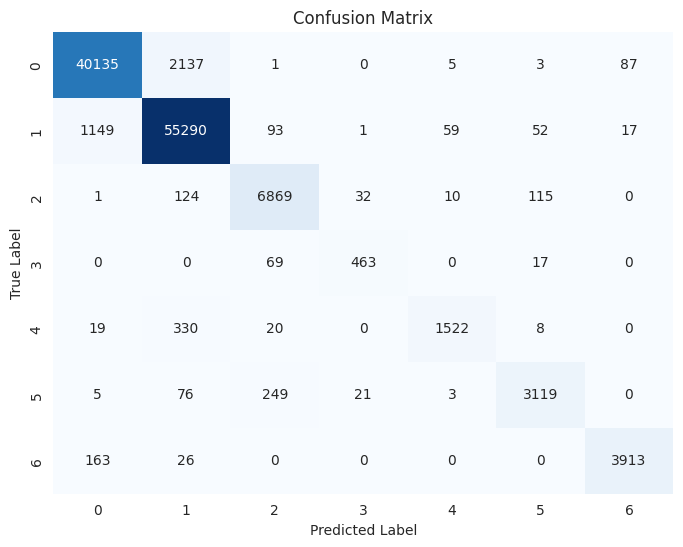

In [ ]:
if 'y_pred' in locals() and y_pred is not None:
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

## 12. & 13. Menampilkan dan Menggambar Feature Importance

Menampilkan kepentingan fitur dari model Random Forest yang telah dilatih dan memvisualisasikannya menggunakan grafik batang.


--- Feature Importance dari Random Forest ---


,Feature,Importance
0,Elevation,0.285369
5,Horizontal_Distance_To_Roadways,0.126379
9,Horizontal_Distance_To_Fire_Points,0.119286
3,Horizontal_Distance_To_Hydrology,0.061501
4,Vertical_Distance_To_Hydrology,0.056646
1,Aspect,0.045878
7,Hillshade_Noon,0.042264
6,Hillshade_9am,0.039611
8,Hillshade_3pm,0.038774
2,Slope,0.030945


/tmp/ipykernel_608/3173575249.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


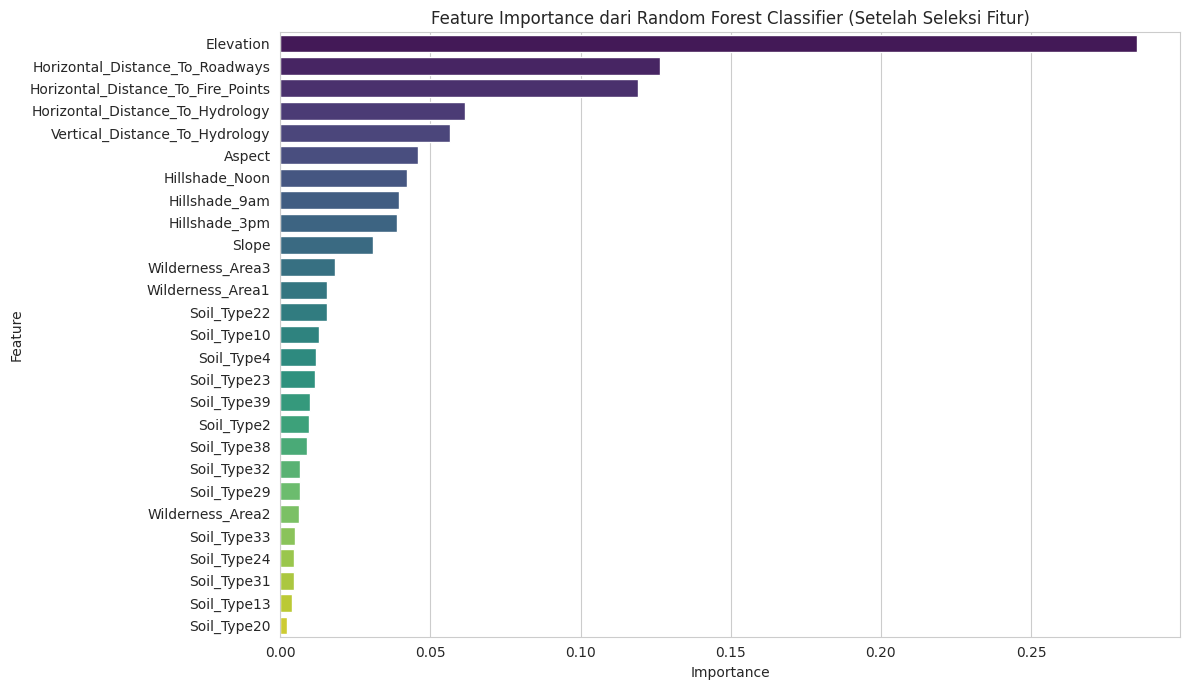

In [ ]:
if 'rf_model' in locals() and rf_model is not None and 'selected_features' in locals():
    feature_importances = rf_model.feature_importances_

    # Membuat DataFrame untuk memudahkan visualisasi
    importance_df = pd.DataFrame({
        'Feature': selected_features,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)

    print("\n--- Feature Importance dari Random Forest ---")
    display(importance_df)

    # Plotting Feature Importance
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
    plt.title('Feature Importance dari Random Forest Classifier (Setelah Seleksi Fitur)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

## 14. Ringkasan Hasil Evaluasi

Bagian ini merangkum semua hasil evaluasi yang telah dihitung sebelumnya.

In [ ]:
if 'accuracy' in locals():
    print("\n--- RINGKASAN HASIL EVALUASI MODEL ---")
    print(f"Model Klasifikasi: Random Forest dengan Seleksi Fitur (Mirip C5.0)")
    print(f"Dataset: {'your_dataset.csv' if df is not None else 'Dataset tidak dimuat'}")
    print(f"Jumlah fitur sebelum seleksi: {X.shape[1] if X is not None else 'N/A'}")
    print(f"Jumlah fitur setelah seleksi: {X_train_selected.shape[1] if 'X_train_selected' in locals() else 'N/A'}")
    print("--------------------------------------")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("--------------------------------------")
    print("Confusion Matrix:")
    print(cm)
    print("--------------------------------------")
    print("Top 10 Feature Importances:")
    display(importance_df.head(10) if 'importance_df' in locals() else 'N/A')


--- RINGKASAN HASIL EVALUASI MODEL ---
Model Klasifikasi: Random Forest dengan Seleksi Fitur (Mirip C5.0)
Dataset: your_dataset.csv
Jumlah fitur sebelum seleksi: 54
Jumlah fitur setelah seleksi: 27
--------------------------------------
Accuracy:  0.9579
Precision: 0.9580
Recall:    0.9579
F1-Score:  0.9577
--------------------------------------
Confusion Matrix:
[[40135  2137     1     0     5     3    87]
 [ 1149 55290    93     1    59    52    17]
 [    1   124  6869    32    10   115     0]
 [    0     0    69   463     0    17     0]
 [   19   330    20     0  1522     8     0]
 [    5    76   249    21     3  3119     0]
 [  163    26     0     0     0     0  3913]]
--------------------------------------
Top 10 Feature Importances:


,Feature,Importance
0,Elevation,0.285369
5,Horizontal_Distance_To_Roadways,0.126379
9,Horizontal_Distance_To_Fire_Points,0.119286
3,Horizontal_Distance_To_Hydrology,0.061501
4,Vertical_Distance_To_Hydrology,0.056646
1,Aspect,0.045878
7,Hillshade_Noon,0.042264
6,Hillshade_9am,0.039611
8,Hillshade_3pm,0.038774
2,Slope,0.030945


In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# ==============================
# TABEL 1: AKURASI MODEL
# ==============================

result_table = pd.DataFrame({
    "Model": ["Random Forest + C5.0 Feature Selection"],
    "Dataset": ["landsat"],
    "Features Before Selection": [X.shape[1]],
    "Features After Selection": [X_train_selected.shape[1]],
    "Accuracy (%)": [accuracy * 100],
    "Precision (%)": [precision * 100],
    "Recall (%)": [recall * 100],
    "F1-Score (%)": [f1 * 100]
})

display(result_table)


# ==============================
# TABEL 2: CONFUSION MATRIX
# ==============================

cm = confusion_matrix(y_test, y_pred)

class_labels = [f"Class {i}" for i in sorted(set(y_test))]

confusion_table = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in class_labels],
    columns=[f"Predicted {label}" for label in class_labels]
)

display(confusion_table)


# ==============================
# TABEL 3: FEATURE IMPORTANCE
# ==============================

feature_table = importance_df.copy()
feature_table.insert(0, "Rank", range(1, len(feature_table) + 1))

display(feature_table.head(10))


# ==============================
# SIMPAN KE EXCEL
# ==============================

with pd.ExcelWriter("tabel_hasil_metode_saya.xlsx") as writer:
    result_table.to_excel(writer, sheet_name="Model Accuracy", index=False)
    confusion_table.to_excel(writer, sheet_name="Confusion Matrix")
    feature_table.to_excel(writer, sheet_name="Feature Importance", index=False)

print("Tabel berhasil dibuat dan disimpan sebagai: tabel_hasil_metode_saya.xlsx")

,Model,Dataset,Features Before Selection,Features After Selection,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Random Forest + C5.0 Feature Selection,landsat,54,27,95.790126,95.800491,95.790126,95.771647


,Predicted Class 0,Predicted Class 1,Predicted Class 2,Predicted Class 3,Predicted Class 4,Predicted Class 5,Predicted Class 6
Actual Class 0,40135,2137,1,0,5,3,87
Actual Class 1,1149,55290,93,1,59,52,17
Actual Class 2,1,124,6869,32,10,115,0
Actual Class 3,0,0,69,463,0,17,0
Actual Class 4,19,330,20,0,1522,8,0
Actual Class 5,5,76,249,21,3,3119,0
Actual Class 6,163,26,0,0,0,0,3913


,Rank,Feature,Importance
0,1,Elevation,0.285369
5,2,Horizontal_Distance_To_Roadways,0.126379
9,3,Horizontal_Distance_To_Fire_Points,0.119286
3,4,Horizontal_Distance_To_Hydrology,0.061501
4,5,Vertical_Distance_To_Hydrology,0.056646
1,6,Aspect,0.045878
7,7,Hillshade_Noon,0.042264
6,8,Hillshade_9am,0.039611
8,9,Hillshade_3pm,0.038774
2,10,Slope,0.030945


Tabel berhasil dibuat dan disimpan sebagai: tabel_hasil_metode_saya.xlsx
